Student task 1: Generation of constellations
1.Generate the constellations for 8-PAM, QPSK, 8-PSK, and 16-QAM. You can assume sqrt(es)=sqrt(Eg)=1
2.Apply Gray encoding, i.e., adjacent symbols (closest ones in the constellation) differ by one binary digit.
3.Plot the respective constellations

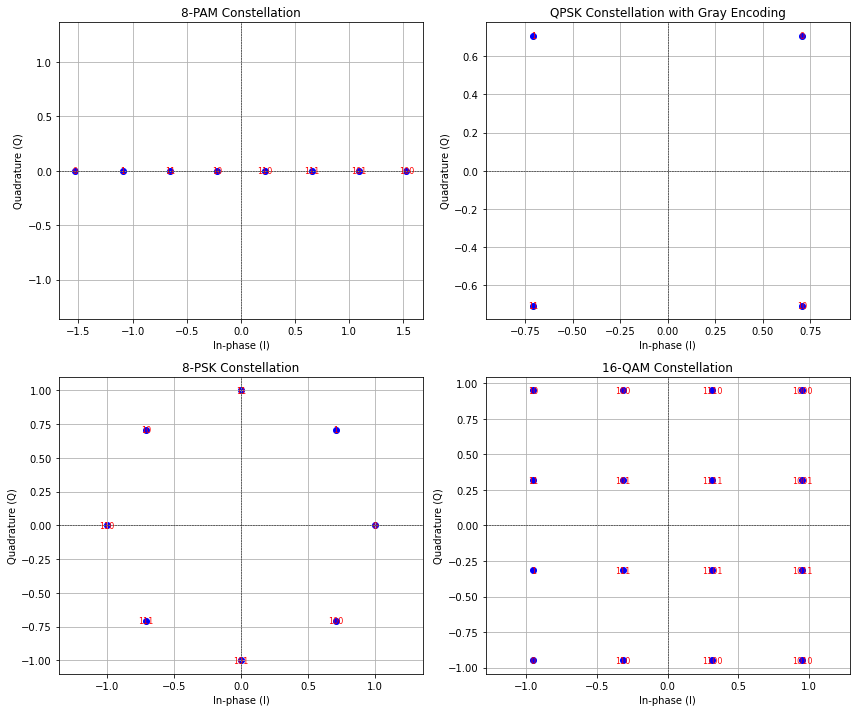

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Constellations
def generate_constellations():
    # 8-PAM (1D constellation)
    M_pam = 8
    pam_symbols = np.linspace(-7, 7, M_pam) / np.sqrt(np.mean(np.square(np.linspace(-7, 7, M_pam))))
    
    # Corrected QPSK (2D constellation)
    qpsk_symbols = [1 + 1j, -1 + 1j, -1 - 1j, 1 - 1j]
    qpsk_symbols = [s / np.sqrt(2) for s in qpsk_symbols]  # Normalize to unit energy

    # 8-PSK (2D constellation)
    M_psk = 8
    psk_symbols = [np.exp(1j * 2 * np.pi * i / M_psk) for i in range(M_psk)]

    # 16-QAM (2D constellation)
    M_qam = 16
    levels = np.linspace(-3, 3, 4)
    qam_symbols = [x + 1j * y for x in levels for y in levels]
    qam_symbols /= np.sqrt(np.mean(np.abs(qam_symbols) ** 2))  # Normalize energy

    return pam_symbols, qpsk_symbols, psk_symbols, qam_symbols

# 2. Apply Gray Encoding
def gray_encoding(M):
    def binary_to_gray(n):
        return n ^ (n >> 1)
    
    return [binary_to_gray(i) for i in range(M)]

# 3. Plot Constellations
def plot_constellation(ax, symbols, title, gray_labels):
    ax.scatter(np.real(symbols), np.imag(symbols), color='blue')
    for i, symbol in enumerate(symbols):
        ax.text(np.real(symbol), np.imag(symbol), f'{gray_labels[i]:b}', fontsize=8, ha='center', va='center', color='red')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(title)
    ax.grid(True)
    ax.set_xlabel("In-phase (I)")
    ax.set_ylabel("Quadrature (Q)")
    ax.axis('equal')

# Generate constellations
pam_symbols, qpsk_symbols, psk_symbols, qam_symbols = generate_constellations()

# Apply Gray encoding to each modulation scheme
pam_gray = gray_encoding(len(pam_symbols))  # Gray encoding for 8-PAM
qpsk_gray = gray_encoding(len(qpsk_symbols))  # Gray encoding for QPSK
psk_gray = gray_encoding(len(psk_symbols))  # Gray encoding for 8-PSK
qam_gray = gray_encoding(len(qam_symbols))  # Gray encoding for 16-QAM

# Plot all constellations in subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot each constellation
plot_constellation(axes[0, 0], pam_symbols, "8-PAM Constellation", pam_gray)
plot_constellation(axes[0, 1], qpsk_symbols, "QPSK Constellation with Gray Encoding", qpsk_gray)
plot_constellation(axes[1, 0], psk_symbols, "8-PSK Constellation", psk_gray)
plot_constellation(axes[1, 1], qam_symbols, "16-QAM Constellation", qam_gray)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()


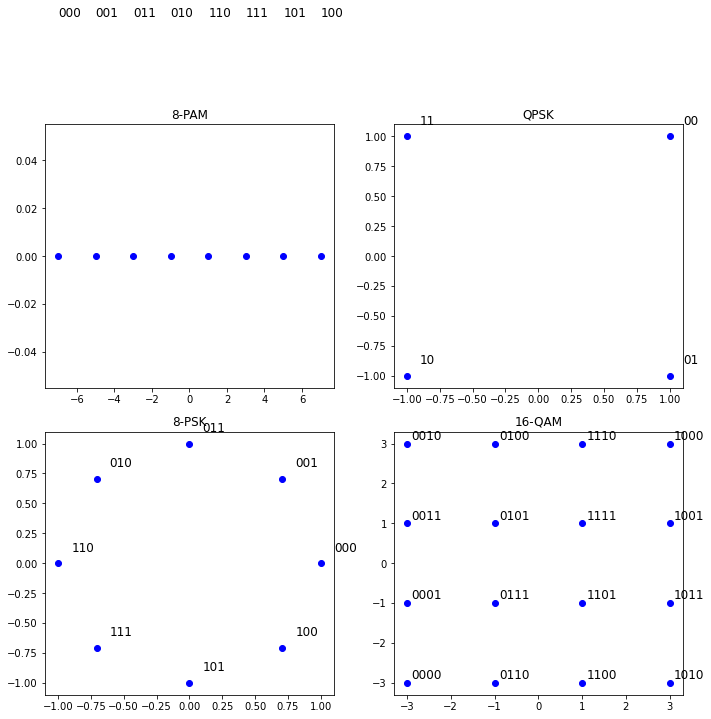

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate Gray code
def gray_code(n):
    if n == 0:
        return ['']
    first_half = gray_code(n - 1)
    second_half = first_half[::-1]
    return ['0' + code for code in first_half] + ['1' + code for code in second_half]

# Generate constellations
def generate_constellations():
    # 8-PAM
    pam8 = np.arange(-7, 8, 2)
    pam8_gray = gray_code(3)
   
    # QPSK
    qpsk = np.array([1+1j, 1-1j, -1+1j, -1-1j])
    qpsk_gray = gray_code(2)
   
    # 8-PSK
    psk8 = np.exp(1j * np.pi / 4 * np.arange(8))
    psk8_gray = gray_code(3)
   
    # 16-QAM
    qam16 = np.array([x + 1j*y for x in [-3, -1, 1, 3] for y in [-3, -1, 1, 3]])
    qam16_gray = gray_code(4)
   
    return pam8, pam8_gray, qpsk, qpsk_gray, psk8, psk8_gray, qam16, qam16_gray

# Plot constellations
def plot_constellations():
    pam8, pam8_gray, qpsk, qpsk_gray, psk8, psk8_gray, qam16, qam16_gray = generate_constellations()
   
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
   
    # Plot 8-PAM
    axs[0, 0].scatter(pam8, np.zeros_like(pam8), c='blue')
    for i in range(len(pam8)):
        axs[0, 0].text(pam8[i], 0.1, pam8_gray[i], fontsize=12)
    axs[0, 0].set_title('8-PAM')
   
    # Plot QPSK
    axs[0, 1].scatter(qpsk.real, qpsk.imag, c='blue')
    for i in range(len(qpsk)):
        axs[0, 1].text(qpsk[i].real + 0.1, qpsk[i].imag + 0.1, qpsk_gray[i], fontsize=12)
    axs[0, 1].set_title('QPSK')
   
    # Plot 8-PSK
    axs[1, 0].scatter(psk8.real, psk8.imag, c='blue')
    for i in range(len(psk8)):
        axs[1, 0].text(psk8[i].real + 0.1, psk8[i].imag + 0.1, psk8_gray[i], fontsize=12)
    axs[1, 0].set_title('8-PSK')
   
    # Plot 16-QAM
    axs[1, 1].scatter(qam16.real, qam16.imag, c='blue')
    for i in range(len(qam16)):
        axs[1, 1].text(qam16[i].real + 0.1, qam16[i].imag + 0.1, qam16_gray[i], fontsize=12)
    axs[1, 1].set_title('16-QAM')
   
    plt.tight_layout()
    plt.show()

plot_constellations()

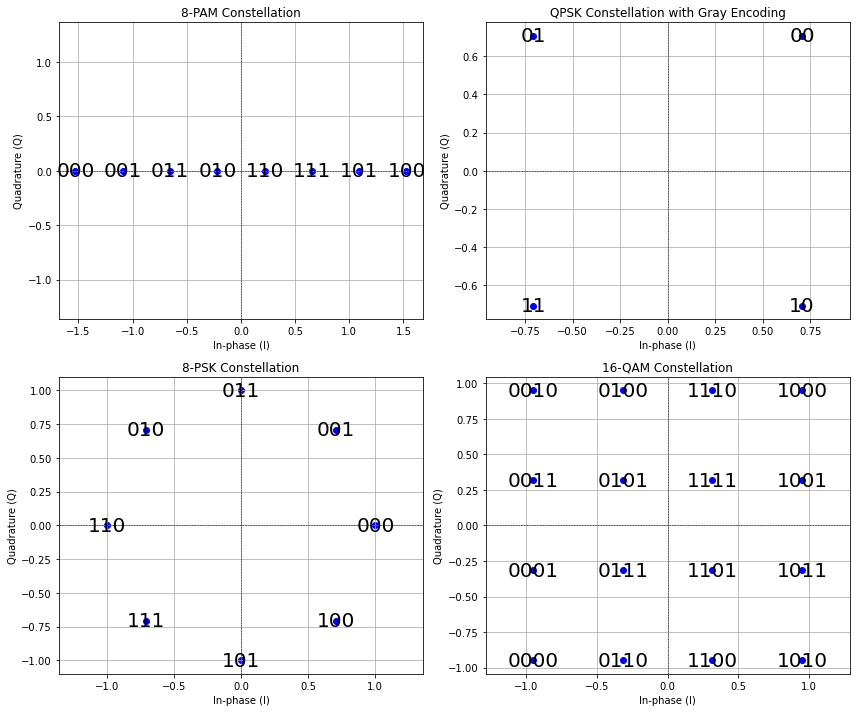

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate Gray code
def gray_code(n):
    if n == 0:
        return ['']
    first_half = gray_code(n - 1)
    second_half = first_half[::-1]
    return ['0' + code for code in first_half] + ['1' + code for code in second_half]

# Generate constellations
def generate_constellations():
    # 8-PAM (1D constellation)
    M_pam = 8
    pam_symbols = np.linspace(-7, 7, M_pam) / np.sqrt(np.mean(np.square(np.linspace(-7, 7, M_pam))))
    pam_gray = gray_code(3)  # 3 bits for 8 levels

    # QPSK (2D constellation)
    qpsk_symbols = [1 + 1j, -1 + 1j, -1 - 1j, 1 - 1j]
    qpsk_symbols = [s / np.sqrt(2) for s in qpsk_symbols]  # Normalize to unit energy
    qpsk_gray = gray_code(2)  # 2 bits for 4 levels

    # 8-PSK (2D constellation)
    M_psk = 8
    psk_symbols = [np.exp(1j * 2 * np.pi * i / M_psk) for i in range(M_psk)]
    psk_gray = gray_code(3)  # 3 bits for 8 levels

    # 16-QAM (2D constellation)
    levels = np.linspace(-3, 3, 4)
    qam_symbols = [x + 1j * y for x in levels for y in levels]
    qam_symbols /= np.sqrt(np.mean(np.abs(qam_symbols) ** 2))  # Normalize energy
    qam_gray = gray_code(4)  # 4 bits for 16 levels

    return pam_symbols, pam_gray, qpsk_symbols, qpsk_gray, psk_symbols, psk_gray, qam_symbols, qam_gray

# Plot constellations
def plot_constellation(ax, symbols, title, gray_labels):
    ax.scatter(np.real(symbols), np.imag(symbols), color='blue')
    for i, symbol in enumerate(symbols):
        ax.text(np.real(symbol), np.imag(symbol), gray_labels[i], fontsize=20, ha='center', va='center', color='black')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(title)
    ax.grid(True)
    ax.set_xlabel("In-phase (I)")
    ax.set_ylabel("Quadrature (Q)")
    ax.axis('equal')

# Main function to generate and plot constellations
def main():
    pam_symbols, pam_gray, qpsk_symbols, qpsk_gray, psk_symbols, psk_gray, qam_symbols, qam_gray = generate_constellations()

    # Plot all constellations in subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Plot each constellation
    plot_constellation(axes[0, 0], pam_symbols, "8-PAM Constellation", pam_gray)
    plot_constellation(axes[0, 1], qpsk_symbols, "QPSK Constellation with Gray Encoding", qpsk_gray)
    plot_constellation(axes[1, 0], psk_symbols, "8-PSK Constellation", psk_gray)
    plot_constellation(axes[1, 1], qam_symbols, "16-QAM Constellation", qam_gray)

    # Adjust layout
    plt.tight_layout()

    # Display the plot
    plt.show()

# Run the program
if __name__ == "__main__":
    main()

Student task 2: Signal transmission through AWGN channel

Complete the code snippet below for each modulation scheme of Student task 1
1.Randomly generate 10^6 symbols to be transmitted.
2.Generate 𝑛(𝑡)
3.Obtain 𝑟(𝑡)
4.Plot the received symbols on the space (noisy constellation).
5.Apply the optimum dectector (minimum distance detector) and obtain the detected symbols.
6.Plot the curves of symbol error rate and bit error rate for the different modultaions for different values of SNR.

In [2]:
SNR_dB = 100
SNR_linear = 10**(SNR_dB / 10)

##For QAM
signal_power = np.mean(np.abs(qam_symbols)**2)
noise_power = signal_power / SNR_linear
num_symbols=len(qam_symbols)

#Generate n(t)
noise = ... 
rx_signal = qam_symbols + noise  

#Plot noisy constellation


# Optimum detector

detected_idx = np.zeros(num_symbols, dtype=int)
for i, r in enumerate(rx_signal):
    distances = ... #use funtion abs
    detected_idx[i] = np.argmin(distances)  
    #....


# Compute symbol error rate 0(SER)
errors = np.sum(qam_symbols != detected_symbols)
SER = errors / num_symbols

# Display results
print(errors)
print("Symbol Error Rate (SER):", SER)




TypeError: unsupported operand type(s) for +: 'complex' and 'ellipsis'

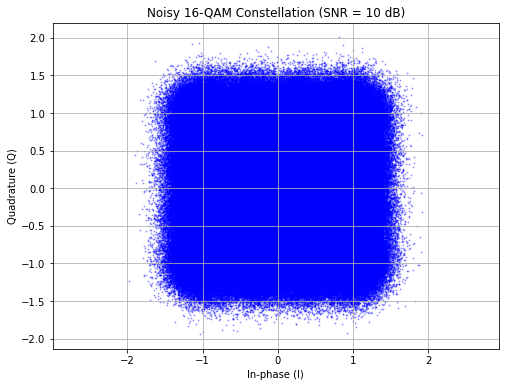

Number of Errors: 221707
Symbol Error Rate (SER): 0.221707


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
SNR_dB = 10
SNR_linear = 10**(SNR_dB / 10)

# Generate QAM Constellation
qam_levels = np.linspace(-3, 3, 4)
qam_symbols = np.array([x + 1j * y for x in qam_levels for y in qam_levels])
qam_symbols /= np.sqrt(np.mean(np.abs(qam_symbols)**2))  # Normalize power

# Signal Power
signal_power = np.mean(np.abs(qam_symbols)**2)

# Noise Power
noise_power = signal_power / SNR_linear

# Number of Symbols
num_symbols = 10**6

# Generate Random Transmitted Symbols
transmitted_idx = np.random.randint(0, len(qam_symbols), num_symbols)
transmitted_symbols = qam_symbols[transmitted_idx]

# Generate n(t) (Noise)
noise = np.sqrt(noise_power / 2) * (np.random.randn(num_symbols) + 1j * np.random.randn(num_symbols))

# Received Signal r(t)
rx_signal = transmitted_symbols + noise

# Plot Noisy Constellation
plt.figure(figsize=(8, 6))
plt.scatter(rx_signal.real, rx_signal.imag, color='blue', alpha=0.3, s=1)
plt.title(f"Noisy 16-QAM Constellation (SNR = {SNR_dB} dB)")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis('equal')
plt.show()

# Optimum Detector (Minimum Distance Detection)
detected_idx = np.zeros(num_symbols, dtype=int)
for i, r in enumerate(rx_signal):
    distances = np.abs(r - qam_symbols)  # Distance to each constellation point
    detected_idx[i] = np.argmin(distances)  # Closest symbol index

# Compute Symbol Error Rate (SER)
errors = np.sum(transmitted_idx != detected_idx)
SER = errors / num_symbols

# Display Results
print("Number of Errors:", errors)
print("Symbol Error Rate (SER):", SER)


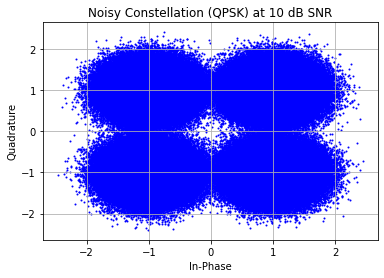

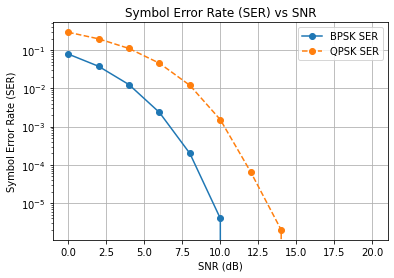

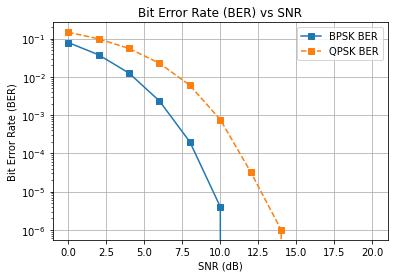

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 10**6  # Number of symbols
SNR_dB_range = np.arange(0, 21, 2)  # SNR range in dB

SER_results = {"BPSK": [], "QPSK": []}
BER_results = {"BPSK": [], "QPSK": []}

# Define constellation points for BPSK and QPSK
constellations = {
    "BPSK": np.array([-1, 1]),
    "QPSK": np.array([-1-1j, -1+1j, 1-1j, 1+1j])
}

# Simulation for BPSK and QPSK
for modulation in ["BPSK", "QPSK"]:
    constellation_points = constellations[modulation]
    M = len(constellation_points)  # Number of constellation points
    bits_per_symbol = int(np.log2(M))

    for SNR_dB in SNR_dB_range:
        # Step 1: Randomly generate symbols to be transmitted
        symbol_indices = np.random.randint(0, M, N)
        transmitted_symbols = constellation_points[symbol_indices]

        # Step 2: Generate AWGN noise
        SNR_linear = 10**(SNR_dB / 10)
        signal_power = np.mean(np.abs(transmitted_symbols)**2)
        noise_power = signal_power / SNR_linear
        noise = np.sqrt(noise_power / 2) * (np.random.randn(N) + 1j * np.random.randn(N))

        # Step 3: Obtain received symbols
        received_symbols = transmitted_symbols + noise

        # Step 4: Plot the received symbols on the space (noisy constellation) for a specific SNR
        if modulation == "QPSK" and SNR_dB == 10:  # Adjust this condition to plot for different cases
            plt.scatter(received_symbols.real, received_symbols.imag, color='blue', s=1)
            plt.title(f'Noisy Constellation ({modulation}) at {SNR_dB} dB SNR')
            plt.xlabel('In-Phase')
            plt.ylabel('Quadrature')
            plt.grid(True)
            plt.show()

        # Step 5: Apply the optimum detector (minimum distance detector)
        detected_idx = np.zeros(N, dtype=int)
        for i, r in enumerate(received_symbols):
            distances = np.abs(constellation_points - r)
            detected_idx[i] = np.argmin(distances)
        detected_symbols = constellation_points[detected_idx]

        # Calculate Symbol Error Rate (SER) and Bit Error Rate (BER)
        SER = np.mean(transmitted_symbols != detected_symbols)
        BER = SER / bits_per_symbol
        SER_results[modulation].append(SER)
        BER_results[modulation].append(BER)

# Step 6: Plot the Symbol Error Rate (SER) curves for different values of SNR
plt.figure()
plt.plot(SNR_dB_range, SER_results["BPSK"], 'o-', label='BPSK SER')
plt.plot(SNR_dB_range, SER_results["QPSK"], 'o--', label='QPSK SER')
plt.title('Symbol Error Rate (SER) vs SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('Symbol Error Rate (SER)')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

# Step 7: Plot the Bit Error Rate (BER) curves for different values of SNR
plt.figure()
plt.plot(SNR_dB_range, BER_results["BPSK"], 's-', label='BPSK BER')
plt.plot(SNR_dB_range, BER_results["QPSK"], 's--', label='QPSK BER')
plt.title('Bit Error Rate (BER) vs SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

Student task 3: Channel coding
1.Generate random information bits (4×106) and store in the variable -data-.
2.Check Example 9.5.4 of the book and the code snippet below, and apply Hamming code (7,4) to the information bits.
3.Apply QPSK or 4-QAM modulation to the coded information.
4.Transmit over an AWGN channel.
5.Decode with hard-decision decoding.
6.Compare the bit error rate of coded and non-coded transmission.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

##Generate random information bits
    
##Apply hamming coding   
def hamming_encode(data):
    if len(data) % 4 != 0:
        raise ValueError("Input data length should be multiple of 4.")

    G = [[1, 0, 0, 1, 0, 1, 1],
         [0, 1, 0, 1, 0, 1, 0],
         [0, 0, 1, 1, 0, 0, 1],
         [0, 0, 0, 0, 1, 1, 1]]

    encoded_data = []
    for k in range(0, len(data), 4):
        block = data[k:k+4]
        for i in range(7):
            sum = 0
            for j in range(4):
                sum += block[j] * G[j][i]
            encoded_data.append(sum % 2)

    return encoded_data

## Modulate with QPSK or 4-QAM

## Transmit symbols throught AWGN channel

## Decode symbols

def hamming_decode(received_data):
    if len(received_data) % 7 != 0:
        raise ValueError("Received data length should be multiple of 7.")

    H = [[1, 0, 1, 0, 1, 0, 1],
         [1, 1, 0, 0, 1, 1, 0],
         [1, 1, 1, 1, 0, 0, 0]]

    decoded_data = []
    for k in range(0, len(received_data), 7):
        block = received_data[k:k+7]
        syndrome = []
        for i in range(3):
            syndrome_sum = 0
            for j in range(7):
                syndrome_sum += block[j] * H[i][j]
            syndrome.append(syndrome_sum % 2)
        error_pos = sum([2 ** i for i, bit in enumerate(syndrome) if bit])
        if error_pos > 0:
            block[7-error_pos] ^= 1  
        decoded_data.extend([block[0], block[1], block[2], block[4]])

    return decoded_data


## Plot bit error rate and compare the performance of coded and non-coded transmission.

plt.figure(2)
plt.semilogy(snr_dbs, ber_encoded, 'o-', label='With Hamming Encoding')
plt.semilogy(snr_dbs, ber_plain, 's-', label='Without Encoding')
plt.title('BER Comparison with and without Hamming Encoding')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.legend()
plt.grid(True)
plt.show()




NameError: name 'snr_dbs' is not defined

<Figure size 640x480 with 0 Axes>

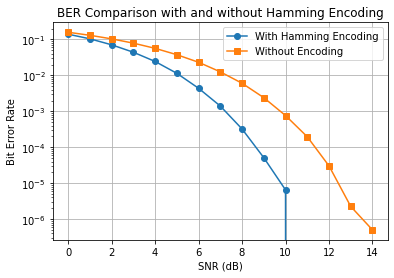

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random information bits
data = np.random.randint(0, 2, 4 * 10**6)

# Apply Hamming coding
def hamming_encode(data):
   if len(data) % 4 != 0:
       raise ValueError("Input data length should be multiple of 4.")
   G = [[1, 0, 0, 1, 0, 1, 1],
        [0, 1, 0, 1, 0, 1, 0],
        [0, 0, 1, 1, 0, 0, 1],
        [0, 0, 0, 0, 1, 1, 1]]
   encoded_data = []
   for k in range(0, len(data), 4):
       block = data[k:k+4]
       for i in range(7):
           sum = 0
           for j in range(4):
               sum += block[j] * G[j][i]
           encoded_data.append(sum % 2)
   return encoded_data

encoded_data = hamming_encode(data)

# Modulate with QPSK or 4-QAM
def qpsk_modulate(data):
   data = np.array(data)
   data = data.reshape((-1, 2))
   symbols = (2*data[:,0] - 1) + 1j*(2*data[:,1] - 1)
   return symbols

modulated_data = qpsk_modulate(encoded_data)

# Transmit symbols through AWGN channel
def awgn_channel(symbols, snr_dB):
   snr_linear = 10**(snr_dB / 10)
   signal_power = np.mean(np.abs(symbols)**2)
   noise_power = signal_power / snr_linear
   noise = np.sqrt(noise_power / 2) * (np.random.randn(len(symbols)) + 1j * np.random.randn(len(symbols)))
   received_symbols = symbols + noise
   return received_symbols

snr_dbs = np.arange(0, 15)
ber_encoded = []
ber_plain = []

for snr_dB in snr_dbs:
   # Transmit encoded symbols
   received_symbols_encoded = awgn_channel(modulated_data, snr_dB)

   # Decode symbols with hard-decision decoding
   def qpsk_demodulate(symbols):
       demod_bits = np.zeros((len(symbols), 2))
       demod_bits[:,0] = np.real(symbols) > 0
       demod_bits[:,1] = np.imag(symbols) > 0
       return demod_bits.flatten().astype(int)

   def hamming_decode(received_data):
       if len(received_data) % 7 != 0:
           raise ValueError("Received data length should be multiple of 7.")
       H = [[1, 0, 1, 0, 1, 0, 1],
            [1, 1, 0, 0, 1, 1, 0],
            [1, 1, 1, 1, 0, 0, 0]]
       decoded_data = []
       for k in range(0, len(received_data), 7):
           block = received_data[k:k+7]
           syndrome = []
           for i in range(3):
               syndrome_sum = 0
               for j in range(7):
                   syndrome_sum += block[j] * H[i][j]
               syndrome.append(syndrome_sum % 2)
           error_pos = sum([2 ** i for i, bit in enumerate(syndrome) if bit])
           if error_pos > 0:
               block[7-error_pos] ^= 1  
           decoded_data.extend([block[0], block[1], block[2], block[4]])
       return decoded_data

   demodulated_bits_encoded = qpsk_demodulate(received_symbols_encoded)
   decoded_bits_encoded = hamming_decode(demodulated_bits_encoded)

   # Calculate BER for encoded transmission
   errors_encoded = np.sum(data != decoded_bits_encoded[:len(data)])
   ber_encoded.append(errors_encoded / len(data))

   # Transmit plain (non-coded) symbols
   modulated_data_plain = qpsk_modulate(data)
   received_symbols_plain = awgn_channel(modulated_data_plain, snr_dB)
   
   # Demodulate plain symbols
   demodulated_bits_plain = qpsk_demodulate(received_symbols_plain)

   # Calculate BER for plain transmission
   errors_plain = np.sum(data != demodulated_bits_plain[:len(data)])
   ber_plain.append(errors_plain / len(data))

# Plot bit error rate and compare the performance of coded and non-coded transmission.
plt.figure()
plt.semilogy(snr_dbs, ber_encoded, 'o-', label='With Hamming Encoding')
plt.semilogy(snr_dbs, ber_plain, 's-', label='Without Encoding')
plt.title('BER Comparison with and without Hamming Encoding')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.legend()
plt.grid(True)
plt.show()